In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/historical_solar_mumbai_clean.csv", parse_dates=["date"])
df.head()

,date,solar_radiation,temp_max,temp_min,humidity,windspeed,day_of_year,month
0,2024-09-06,3.8534,29.35,25.03,89.96,5.07,250,9
1,2024-09-07,5.4259,29.23,24.70,90.29,3.95,251,9
2,2024-09-08,6.0778,29.05,24.59,91.03,3.42,252,9
3,2024-09-09,5.4350,29.70,24.70,89.52,3.27,253,9
4,2024-09-10,4.9025,29.15,24.71,89.76,3.40,254,9


In [2]:
print(f"Rows: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.describe()

Rows: 722
Date range: 2024-09-06 00:00:00 to 2026-08-28 00:00:00


,date,solar_radiation,temp_max,temp_min,humidity,windspeed,day_of_year,month
count,722,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000
mean,2025-09-01 12:00:00,4.906450,32.726233,22.612175,69.743172,3.624571,182.480609,6.502770
min,2024-09-06 00:00:00,0.324000,25.730000,13.160000,17.610000,1.440000,1.000000,1.000000
25%,2025-03-05 06:00:00,4.090375,29.150000,19.722500,55.745000,2.790000,91.000000,4.000000
50%,2025-09-01 12:00:00,4.922650,31.245000,23.955000,70.215000,3.335000,181.000000,6.000000
75%,2026-02-28 18:00:00,6.094025,36.237500,25.320000,88.545000,4.000000,275.750000,10.000000
max,2026-08-28 00:00:00,7.712400,44.100000,29.500000,94.700000,9.430000,366.000000,12.000000
std,NaN,1.514377,4.414940,3.885374,18.487296,1.251364,106.012706,3.461798


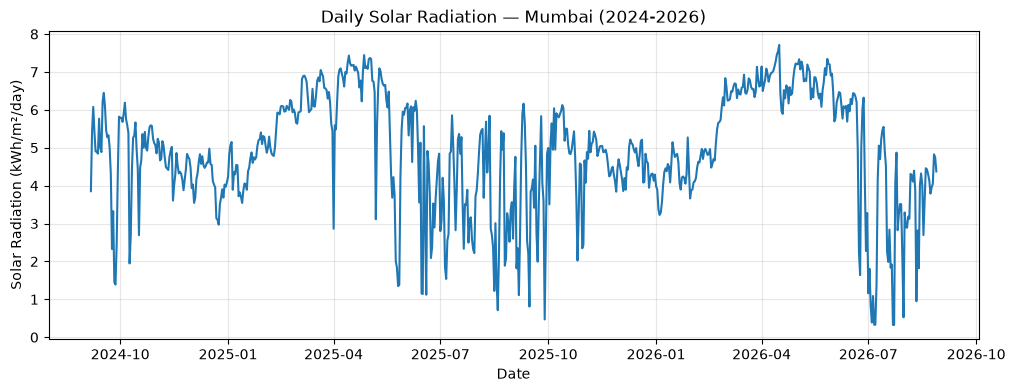

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["solar_radiation"])
plt.title("Daily Solar Radiation — Mumbai (2024-2026)")
plt.xlabel("Date")
plt.ylabel("Solar Radiation (kWh/m²/day)")
plt.grid(True, alpha=0.3)
plt.show()

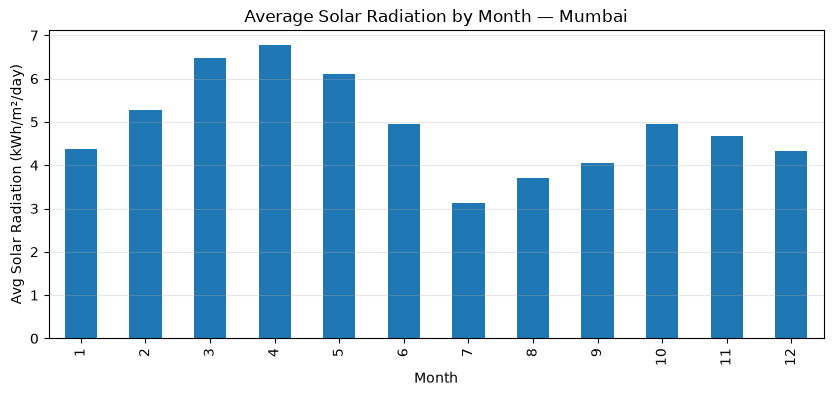

In [4]:
monthly_avg = df.groupby("month")["solar_radiation"].mean()

plt.figure(figsize=(10, 4))
monthly_avg.plot(kind="bar")
plt.title("Average Solar Radiation by Month — Mumbai")
plt.xlabel("Month")
plt.ylabel("Avg Solar Radiation (kWh/m²/day)")
plt.grid(True, alpha=0.3, axis="y")
plt.show()

In [5]:
correlation_cols = ["solar_radiation", "temp_max", "temp_min", "humidity", "windspeed"]
correlation_matrix = df[correlation_cols].corr()
correlation_matrix

,solar_radiation,temp_max,temp_min,humidity,windspeed
solar_radiation,1.000000,0.739796,0.083724,-0.610008,-0.434994
temp_max,0.739796,1.000000,0.209094,-0.820274,-0.286803
temp_min,0.083724,0.209094,1.000000,0.306007,0.224895
humidity,-0.610008,-0.820274,0.306007,1.000000,0.300631
windspeed,-0.434994,-0.286803,0.224895,0.300631,1.000000


In [6]:
monthly_avg = df.groupby("month")["solar_radiation"].mean()
monthly_avg

month
1     4.382715
2     5.285673
3     6.479156
4     6.775405
5     6.112216
6     4.947227
7     3.128563
8     3.701461
9     4.058485
10    4.946085
11    4.664668
12    4.332206
Name: solar_radiation, dtype: float64